# 10 — Manifolds, Charts, and Why the Axioms Are There

> *Every condition in the definition exists to exclude a specific monster. Here are the monsters.*

## The one-paragraph answer

Notebook 08 built a ladder — metric $\to$ normed $\to$ Banach $\to$ Hilbert — where each rung
**adds structure to gain power**. The manifold axioms work the **opposite** way. They are
**restrictions that exclude pathologies**.

"Hausdorff" does not let you do anything new. It stops a space where a sequence converges to
*two different points* from being called a manifold. "Second-countable" does not add an
operation; it rules out a space too big to integrate over. This is exactly why the definition
feels like arbitrary bureaucracy on first reading: **the motivation lives entirely in
counterexamples nobody shows you.**

So this notebook shows them. Every axiom gets a concrete object that satisfies everything
*except* that one condition, and a computation demonstrating what breaks.

## The definition we are dismantling

A **topological manifold of dimension $n$** is a topological space $M$ that is

1. **locally Euclidean** — every point has a neighbourhood homeomorphic to an open subset of $\mathbb{R}^n$,
2. **Hausdorff** — distinct points have disjoint neighbourhoods,
3. **second-countable** — the topology has a countable base.

A **smooth manifold** adds a fourth: an atlas whose **transition maps are smooth**.

| Condition | §  | Drop it and you get | What breaks |
|---|---|---|---|
| locally Euclidean | 1, 5 | figure-eight; a cone (smoothly) | charts do not exist |
| **Hausdorff** | 3 | line with two origins | limits are not unique |
| **second-countable** | 4 | the long line | no partitions of unity $\Rightarrow$ no integration |
| smooth transitions | 7 | $\mathbb{R}$ with the chart $x\mapsto x^3$ | calculus is chart-dependent |

## Where this sits in the series

| Notebook | Adds | Gets you |
|---|---|---|
| **10 (this one)** | — | a manifold: calculus on a curved space |
| 09 | + a group structure | Lie group, Lie algebra |
| 07 | + a metric on each tangent space | Riemannian/Lorentzian geometry, curvature, GR |

Notebook 09 §2.1 asserted "a manifold locally looks like $\mathbb{R}^n$" and moved on.
This is that sentence, unpacked.

*Companion to the [Manifolds lecture series](https://www.youtube.com/playlist?list=PLBh2i93oe2qvRGAtgkTszX7szZDVd6jh1)
by The Bright Side of Mathematics.*

---
## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.linalg import norm as sla_norm
from scipy.integrate import quad

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
    'figure.dpi': 100
})
sns.set_style("whitegrid")
np.set_printoptions(precision=5, suppress=True)
rng = np.random.default_rng(0)
print(f"numpy {np.__version__}")

numpy 2.2.6


---
## 1. Charts, atlases, transition maps

A **chart** is a homeomorphism $\varphi: U \to \varphi(U) \subseteq \mathbb{R}^n$ from an open
piece of $M$ to a flat piece of $\mathbb{R}^n$. It is a coordinate system valid on part of the
space. An **atlas** is a collection of charts covering all of $M$.

The essential point, and the reason the whole subject exists: **one chart is usually not
enough.** You cannot cover a sphere with a single coordinate patch. So you need several,
and then you need to know how they agree where they overlap — that is the **transition map**

$$\varphi_2 \circ \varphi_1^{-1} : \varphi_1(U_1\cap U_2) \to \varphi_2(U_1\cap U_2)$$

which lives entirely in $\mathbb{R}^n$, so you can ask whether it is continuous, smooth, etc.
**A manifold is smooth when all its transition maps are smooth.** That is the whole
definition — smoothness is a statement about the overlaps, never about the space itself.

### 1.1 The circle $S^1$ with two charts

Stereographic projection from the north pole covers everything but $N$; from the south pole,
everything but $S$. Together they cover $S^1$.

In [2]:
# S^1 = {(x,y) : x^2 + y^2 = 1}
def stereo_N(p):          # project from N=(0,1) onto the x-axis; undefined at N
    x, y = p
    return x / (1 - y)

def stereo_N_inv(u):
    return np.array([2*u, u**2 - 1]) / (u**2 + 1)

def stereo_S(p):          # project from S=(0,-1); undefined at S
    x, y = p
    return x / (1 + y)

def stereo_S_inv(v):
    return np.array([2*v, 1 - v**2]) / (v**2 + 1)

th = np.linspace(0, 2*np.pi, 400)
circle = np.column_stack([np.cos(th), np.sin(th)])

# round-trip check on points away from the poles
pts = circle[(np.abs(circle[:,1] - 1) > 1e-6) & (np.abs(circle[:,1] + 1) > 1e-6)][::7]
errN = max(sla_norm(stereo_N_inv(stereo_N(p)) - p) for p in pts)
errS = max(sla_norm(stereo_S_inv(stereo_S(p)) - p) for p in pts)
print(f"chart N round-trip error : {errN:.2e}")
print(f"chart S round-trip error : {errS:.2e}")
print(f"\nchart N covers S^1 minus N=(0,1);  chart S covers S^1 minus S=(0,-1)")
print(f"together they cover everything -> a valid ATLAS with 2 charts")
print(f"\nOne chart is not enough: S^1 is compact, open subsets of R are not,")
print(f"and a homeomorphism preserves compactness. So no single chart can work.")

chart N round-trip error : 8.33e-16
chart S round-trip error : 7.63e-16

chart N covers S^1 minus N=(0,1);  chart S covers S^1 minus S=(0,-1)
together they cover everything -> a valid ATLAS with 2 charts

One chart is not enough: S^1 is compact, open subsets of R are not,
and a homeomorphism preserves compactness. So no single chart can work.


transition map  phi_S . phi_N^{-1}  computed numerically vs 1/u:
   max |v - 1/u| = 3.55e-13



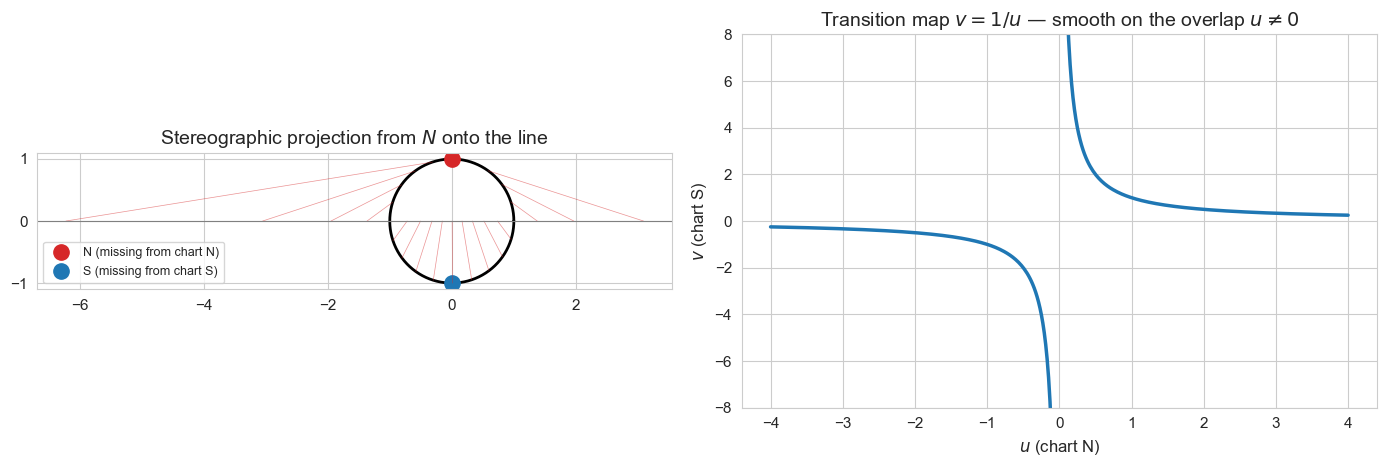

v = 1/u is C-infinity on u != 0, which IS the overlap (u=0 is the point S,
which chart S does not contain). So S^1 is a SMOOTH manifold.

Note what was checked: a map from R to R. Never the circle itself.


In [3]:
# The transition map. On the overlap (everything except both poles):
#     v = stereo_S(stereo_N_inv(u)) = 1/u
us = np.concatenate([np.linspace(-4, -0.05, 200), np.linspace(0.05, 4, 200)])
vs = np.array([stereo_S(stereo_N_inv(u)) for u in us])

print("transition map  phi_S . phi_N^{-1}  computed numerically vs 1/u:")
print(f"   max |v - 1/u| = {np.abs(vs - 1/us).max():.2e}\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(circle[:,0], circle[:,1], 'k', lw=2)
for p, c, lab in [((0,1),'C3','N (missing from chart N)'), ((0,-1),'C0','S (missing from chart S)')]:
    axes[0].plot(*p, 'o', color=c, ms=11, label=lab)
sample = circle[::20]
for p in sample:
    if abs(p[1]-1) > .05:
        axes[0].plot([p[0], stereo_N(p)], [p[1], 0], color='C3', lw=.5, alpha=.5)
axes[0].axhline(0, color='grey', lw=.8)
axes[0].set_aspect('equal'); axes[0].legend(fontsize=9)
axes[0].set_title("Stereographic projection from $N$ onto the line")

axes[1].plot(us[us<0], vs[us<0], lw=2.5, color='C0')
axes[1].plot(us[us>0], vs[us>0], lw=2.5, color='C0')
axes[1].set_ylim(-8, 8); axes[1].set_xlabel("$u$ (chart N)"); axes[1].set_ylabel("$v$ (chart S)")
axes[1].set_title("Transition map $v = 1/u$ — smooth on the overlap $u \\neq 0$")
plt.tight_layout(); plt.show()

print("v = 1/u is C-infinity on u != 0, which IS the overlap (u=0 is the point S,")
print("which chart S does not contain). So S^1 is a SMOOTH manifold.")
print("\nNote what was checked: a map from R to R. Never the circle itself.")

### 1.2 The sphere $S^2$ — same construction, one dimension up

S^2 chart round-trip error : 7.72e-16
transition map == (u,v)/(u^2+v^2) : max err 3.55e-15

smooth everywhere except (0,0) -- which is the north pole, not in the overlap.
=> S^2 is a smooth 2-manifold with a 2-chart atlas.


/Users/alexchilton/Library/Python/3.12/lib/python/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Users/alexchilton/Library/Python/3.12/lib/python/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


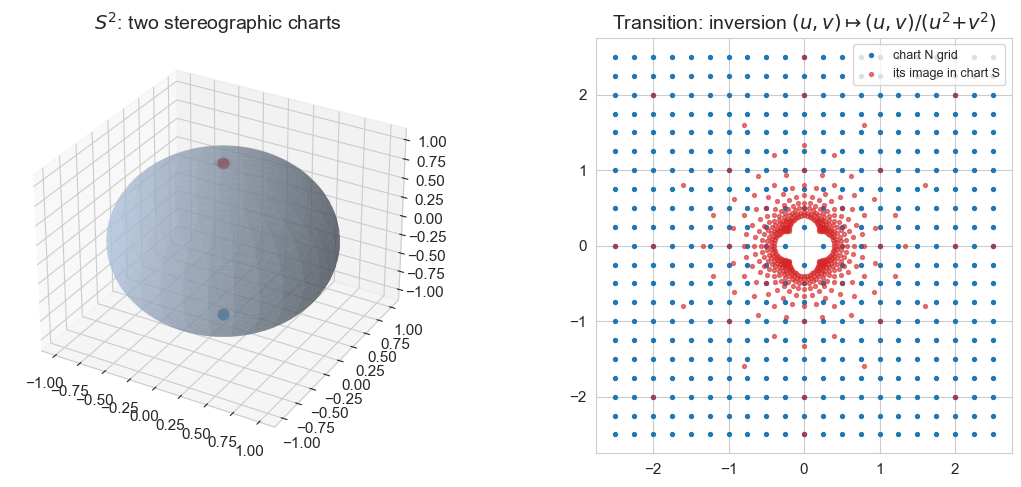

In [4]:
def sphere_N(p):                       # R^3 -> R^2, from the north pole
    x, y, z = p
    return np.array([x, y]) / (1 - z)

def sphere_N_inv(uv):
    u, v = uv; s = u*u + v*v
    return np.array([2*u, 2*v, s - 1]) / (s + 1)

def sphere_S(p):
    x, y, z = p
    return np.array([x, y]) / (1 + z)

# random points away from the poles
P = rng.normal(size=(500, 3)); P /= np.linalg.norm(P, axis=1, keepdims=True)
P = P[np.abs(P[:, 2]) < 0.95]
err = max(sla_norm(sphere_N_inv(sphere_N(p)) - p) for p in P)
print(f"S^2 chart round-trip error : {err:.2e}")

# transition map: (u,v) -> (u,v)/(u^2+v^2)   [inversion in the unit circle]
UV = rng.normal(size=(400, 2)) * 1.5
UV = UV[np.linalg.norm(UV, axis=1) > 0.2]
lhs = np.array([sphere_S(sphere_N_inv(uv)) for uv in UV])
rhs = UV / (np.sum(UV**2, axis=1, keepdims=True))
print(f"transition map == (u,v)/(u^2+v^2) : max err {np.abs(lhs - rhs).max():.2e}")
print("\nsmooth everywhere except (0,0) -- which is the north pole, not in the overlap.")
print("=> S^2 is a smooth 2-manifold with a 2-chart atlas.")

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
u_, v_ = np.mgrid[0:2*np.pi:60j, 0:np.pi:40j]
ax.plot_surface(np.cos(u_)*np.sin(v_), np.sin(u_)*np.sin(v_), np.cos(v_),
                color='lightsteelblue', alpha=.55, linewidth=0)
ax.scatter(0, 0, 1, color='C3', s=60); ax.scatter(0, 0, -1, color='C0', s=60)
ax.set_title("$S^2$: two stereographic charts")

ax2 = fig.add_subplot(1, 2, 2)
g = np.linspace(-2.5, 2.5, 21)
GX, GY = np.meshgrid(g, g)
mask = (GX**2 + GY**2) > 0.04
TX = GX/(GX**2+GY**2+1e-12); TY = GY/(GX**2+GY**2+1e-12)
ax2.scatter(GX[mask], GY[mask], s=8, color='C0', label='chart N grid')
ax2.scatter(np.clip(TX[mask],-2.5,2.5), np.clip(TY[mask],-2.5,2.5),
            s=8, color='C3', alpha=.6, label='its image in chart S')
ax2.set_aspect('equal'); ax2.legend(fontsize=9)
ax2.set_title("Transition: inversion $(u,v)\\mapsto (u,v)/(u^2{+}v^2)$")
plt.tight_layout(); plt.show()

---
## 2. Quotients — how manifolds are actually built

Most manifolds are not handed to you as subsets of $\mathbb{R}^n$. They are built by
**gluing**: take a simple space and declare some points equal. Formally that is a
**quotient space** $X/\!\sim$, whose open sets are the sets whose preimages are open.

| Manifold | Built as | Gluing rule |
|---|---|---|
| circle $S^1$ | $[0,1]/\sim$ | $0 \sim 1$ |
| torus $T^2$ | $\mathbb{R}^2/\mathbb{Z}^2$ | $(x,y)\sim(x{+}m,\,y{+}n)$ |
| Möbius band | $[0,1]\times(-1,1)/\sim$ | $(0,t)\sim(1,-t)$ — note the flip |
| projective plane $\mathbb{RP}^2$ | $S^2/\sim$ | $p \sim -p$ (antipodes) |
| Klein bottle | square | one pair flipped, one not |

Quotients are also how the monsters get built (§3), so the machinery is worth having.

The quotient identification, checked:
   (x,y)=(0.3, 0.0) and (0.3, 1.0) -> same point? distance 1.96e-16
   (x,y)=(0.0, 0.7) and (1.0, 0.7) -> same point? distance 4.29e-16
   (x,y)=(0.2, 0.4) and (3.2, -2.6) -> same point? distance 1.18e-15

Every point of R^2 maps somewhere; points differing by an integer vector
map to the SAME place. That is exactly R^2/Z^2.


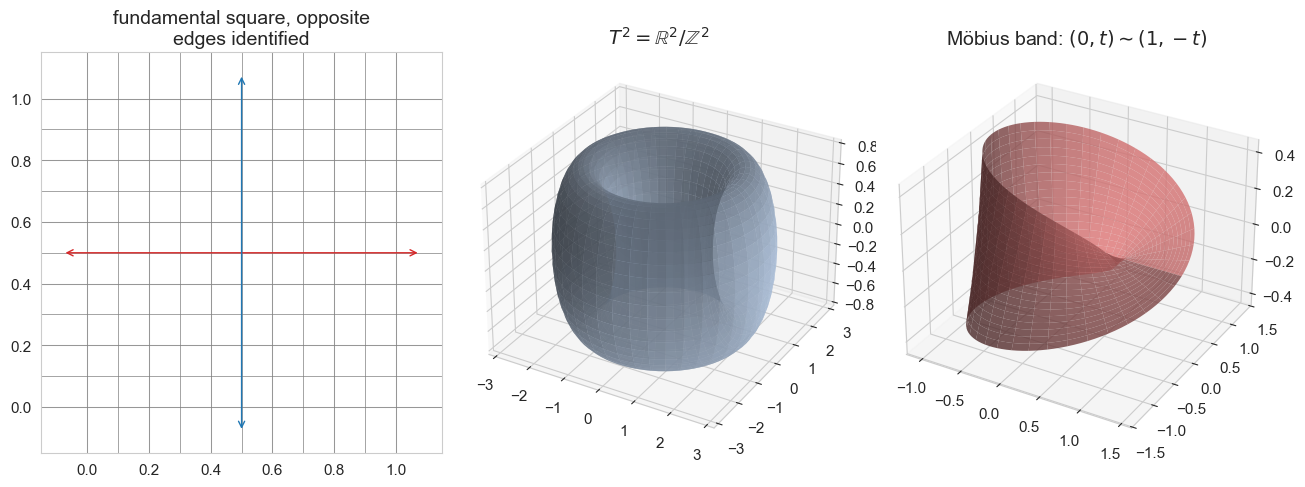


Möbius gluing check: mobius(0, t) vs mobius(1, -t)
   t=+0.3: distance 2.78e-16
   t=-0.6: distance 1.82e-16
   t=+0.9: distance 3.48e-16


In [5]:
# Torus as R^2 / Z^2: coordinates are taken mod 1.
def torus_embed(x, y, R=2.0, r=0.8):
    a, b = 2*np.pi*x, 2*np.pi*y
    return np.array([(R + r*np.cos(b))*np.cos(a),
                     (R + r*np.cos(b))*np.sin(a),
                     r*np.sin(b)])

print("The quotient identification, checked:")
for p, q in [((0.3, 0.0), (0.3, 1.0)), ((0.0, 0.7), (1.0, 0.7)), ((0.2, 0.4), (3.2, -2.6))]:
    d = sla_norm(torus_embed(*p) - torus_embed(*q))
    print(f"   (x,y)={p} and {q} -> same point? distance {d:.2e}")

print("\nEvery point of R^2 maps somewhere; points differing by an integer vector")
print("map to the SAME place. That is exactly R^2/Z^2.")

fig = plt.figure(figsize=(13, 4.8))
ax = fig.add_subplot(1, 3, 1)
gx = np.linspace(0, 1, 11)
for g in gx:
    ax.axvline(g, color='grey', lw=.5); ax.axhline(g, color='grey', lw=.5)
ax.annotate('', xy=(1.08, .5), xytext=(-.08, .5), arrowprops=dict(arrowstyle='<->', color='C3'))
ax.annotate('', xy=(.5, 1.08), xytext=(.5, -.08), arrowprops=dict(arrowstyle='<->', color='C0'))
ax.set_xlim(-.15, 1.15); ax.set_ylim(-.15, 1.15); ax.set_aspect('equal')
ax.set_title("fundamental square, opposite\nedges identified")

ax2 = fig.add_subplot(1, 3, 2, projection='3d')
U, V = np.mgrid[0:1:80j, 0:1:40j]
E = np.array([[torus_embed(U[i,j], V[i,j]) for j in range(U.shape[1])] for i in range(U.shape[0])])
ax2.plot_surface(E[:,:,0], E[:,:,1], E[:,:,2], color='lightsteelblue', alpha=.75, linewidth=0)
ax2.set_title("$T^2 = \\mathbb{R}^2/\\mathbb{Z}^2$")

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
def mobius(s, t, w=0.45):
    a = 2*np.pi*s
    return np.array([(1 + w*t*np.cos(a/2))*np.cos(a),
                     (1 + w*t*np.cos(a/2))*np.sin(a),
                     w*t*np.sin(a/2)])
S_, T_ = np.mgrid[0:1:120j, -1:1:20j]
M = np.array([[mobius(S_[i,j], T_[i,j]) for j in range(S_.shape[1])] for i in range(S_.shape[0])])
ax3.plot_surface(M[:,:,0], M[:,:,1], M[:,:,2], color='lightcoral', alpha=.8, linewidth=0)
ax3.set_title("Möbius band: $(0,t)\\sim(1,-t)$")
plt.tight_layout(); plt.show()

print(f"\nMöbius gluing check: mobius(0, t) vs mobius(1, -t)")
for t in [0.3, -0.6, 0.9]:
    print(f"   t={t:+.1f}: distance {sla_norm(mobius(0,t) - mobius(1,-t)):.2e}")

---
## 3. Why Hausdorff — the line with two origins

Here is a space that is **locally Euclidean** and **second-countable**, and is still not a
manifold, because limits stop being unique.

**Construction.** Take two copies of $\mathbb{R}$, tag them $a$ and $b$, and glue every
nonzero point to its twin — but leave the two zeros unglued:

$$L = \big(\mathbb{R}\times\{a,b\}\big)\big/\big((x,a)\sim(x,b) \text{ for } x \ne 0\big)$$

The result is a line with **two distinct origins**, $0_a$ and $0_b$.

It is locally Euclidean: $U_a = (\mathbb{R}\setminus\{0\})\cup\{0_a\}$ is homeomorphic to
$\mathbb{R}$, and so is $U_b$. Two charts, both perfect. Second-countable too.

**But it is not Hausdorff.** Every neighbourhood of $0_a$ and every neighbourhood of $0_b$
must contain a punctured interval around $0$ — and those *always intersect*. You cannot
separate the two origins.

In [6]:
# Represent a point as (value, tag). tag is None for ordinary points, 'a'/'b' for the origins.
def L_point(x, tag=None):
    return (0.0, tag) if x == 0 else (float(x), None)

def basic_nbhd(pt, eps):
    # A basic open set around pt: for an origin, the punctured interval plus that origin.
    x, tag = pt
    if tag is None:
        return ('interval', x - eps, x + eps, None)
    return ('origin_nbhd', -eps, eps, tag)

def intersects(A, B):
    # do two basic open sets share a point?  (punctured intervals always do if they overlap)
    _, la, ra, ta = A
    _, lb, rb, tb = B
    lo, hi = max(la, lb), min(ra, rb)
    if hi <= lo:
        return False
    # the shared region is a nonempty interval; it contains nonzero points, which are
    # single shared points of L regardless of the tags
    return True

Oa, Ob = L_point(0, 'a'), L_point(0, 'b')
print("Trying to separate the two origins 0_a and 0_b with disjoint neighbourhoods:\n")
print(f"{'eps_a':>10} {'eps_b':>10}   disjoint?")
print("-" * 36)
for ea, eb in [(1.0, 1.0), (0.1, 0.1), (1e-3, 1e-3), (1e-9, 1e-9), (1e-15, 1e-300)]:
    A, B = basic_nbhd(Oa, ea), basic_nbhd(Ob, eb)
    print(f"{ea:>10.0e} {eb:>10.0e}   {'YES' if not intersects(A,B) else 'no - they always overlap'}")
print("\nNo matter how small, both neighbourhoods contain the punctured interval")
print("(0, min(eps_a,eps_b)), whose points are SHARED. => NOT Hausdorff.")

Trying to separate the two origins 0_a and 0_b with disjoint neighbourhoods:

     eps_a      eps_b   disjoint?
------------------------------------
     1e+00      1e+00   no - they always overlap
     1e-01      1e-01   no - they always overlap
     1e-03      1e-03   no - they always overlap
     1e-09      1e-09   no - they always overlap
     1e-15     1e-300   no - they always overlap

No matter how small, both neighbourhoods contain the punctured interval
(0, min(eps_a,eps_b)), whose points are SHARED. => NOT Hausdorff.


sequence x_n = 1/n  in the line with two origins

   n          x_n    |x_n - 0_a|    |x_n - 0_b|
------------------------------------------------
   1     1.000000       1.000000       1.000000
   2     0.500000       0.500000       0.500000
   3     0.333333       0.333333       0.333333
   4     0.250000       0.250000       0.250000
   5     0.200000       0.200000       0.200000
   6     0.166667       0.166667       0.166667
   7     0.142857       0.142857       0.142857
   8     0.125000       0.125000       0.125000
   9     0.111111       0.111111       0.111111
  10     0.100000       0.100000       0.100000
  11     0.090909       0.090909       0.090909

Every neighbourhood of 0_a contains the tail of the sequence  -> x_n -> 0_a
Every neighbourhood of 0_b contains the tail of the sequence  -> x_n -> 0_b
0_a != 0_b.  THE LIMIT IS NOT UNIQUE.

That is the entire content of the Hausdorff axiom: it is there so that
'the limit' is a well-defined phrase. Nothing more, nothing le

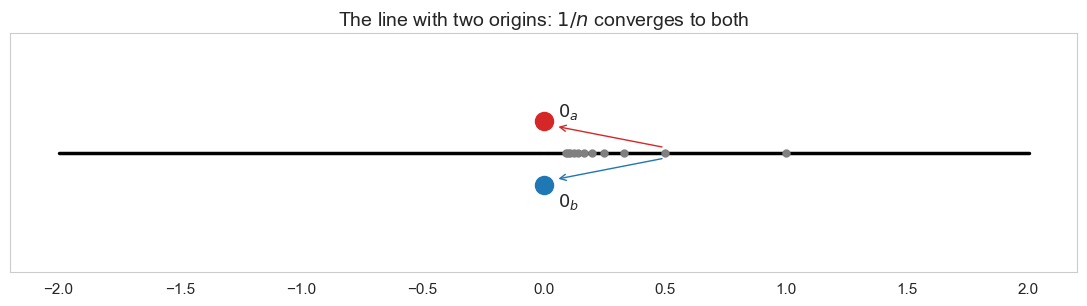

In [7]:
# The consequence: a sequence with TWO distinct limits.
n = np.arange(1, 12)
seq = 1.0 / n
print("sequence x_n = 1/n  in the line with two origins\n")
print(f"{'n':>4} {'x_n':>12} {'|x_n - 0_a|':>14} {'|x_n - 0_b|':>14}")
print("-" * 48)
for k, x in zip(n, seq):
    print(f"{k:>4} {x:>12.6f} {x:>14.6f} {x:>14.6f}")

print("\nEvery neighbourhood of 0_a contains the tail of the sequence  -> x_n -> 0_a")
print("Every neighbourhood of 0_b contains the tail of the sequence  -> x_n -> 0_b")
print("0_a != 0_b.  THE LIMIT IS NOT UNIQUE.")
print("\nThat is the entire content of the Hausdorff axiom: it is there so that")
print("'the limit' is a well-defined phrase. Nothing more, nothing less.")

fig, ax = plt.subplots(figsize=(11, 3.2))
xs = np.linspace(-2, 2, 500)
ax.plot(xs[xs<0], np.zeros_like(xs[xs<0]), 'k', lw=2.5)
ax.plot(xs[xs>0], np.zeros_like(xs[xs>0]), 'k', lw=2.5)
ax.plot(0, 0.12, 'o', color='C3', ms=13); ax.text(0.06, 0.14, "$0_a$", fontsize=13)
ax.plot(0, -0.12, 'o', color='C0', ms=13); ax.text(0.06, -0.20, "$0_b$", fontsize=13)
ax.plot(seq, np.zeros_like(seq), 'o', color='grey', ms=5)
ax.annotate('', xy=(0.05, 0.10), xytext=(0.5, 0.02), arrowprops=dict(arrowstyle='->', color='C3'))
ax.annotate('', xy=(0.05, -0.10), xytext=(0.5, -0.02), arrowprops=dict(arrowstyle='->', color='C0'))
ax.set_ylim(-0.45, 0.45); ax.set_yticks([]); ax.grid(False)
ax.set_title("The line with two origins: $1/n$ converges to both")
plt.tight_layout(); plt.show()

**Why you actually care.** Without Hausdorff:

- "the limit of $x_n$" is not a definition, so continuity arguments lose their meaning;
- compact subsets need not be closed;
- solutions of ODEs on the space are not unique — the flow can split at the doubled point;
- you cannot embed the space in any $\mathbb{R}^N$.

Note that this space is perfectly good *locally*. The pathology is entirely global, which is
why "locally Euclidean" alone is not enough.

---
## 4. Why second-countable — and what partitions of unity buy

**Second-countable** means the topology has a countable base. The standard monster that
fails it is the **long line**: glue together uncountably many copies of $[0,1)$, indexed by
the first uncountable ordinal $\omega_1$. It is locally Euclidean *and* Hausdorff, and still
not a manifold. It is "longer than $\mathbb{R}$" — too long to be covered by countably many
charts, so it embeds in no $\mathbb{R}^N$.

We cannot compute with ordinals here. But we can demonstrate exactly **what
second-countability buys**, which is the honest version of the question: it gives
(with local compactness and Hausdorff) **paracompactness**, and therefore **partitions of
unity**.

A partition of unity subordinate to a cover $\{U_i\}$ is a family of smooth bumps
$\rho_i \ge 0$ with $\operatorname{supp}\rho_i \subset U_i$ and $\sum_i \rho_i \equiv 1$.

That is the tool that lets you take things defined **chart by chart** and assemble them into
one global object. Without it there is no integration on a manifold, no Riemannian metric
built from local pieces, no Stokes' theorem.

In [8]:
# The standard smooth bump: f(t) = exp(-1/t) for t>0, 0 otherwise. C-infinity but NOT analytic.
def f(t):
    out = np.zeros_like(np.asarray(t, dtype=float))
    m = np.asarray(t, dtype=float) > 0
    out[m] = np.exp(-1.0 / np.asarray(t, dtype=float)[m])
    return out

def smooth_step(t):          # 0 for t<=0, 1 for t>=1, smooth in between
    return f(t) / (f(t) + f(1 - t))

def bump(x, a, b, c, d):     # 0 outside [a,d], 1 on [b,c], smooth everywhere
    return smooth_step((x - a) / (b - a)) * smooth_step((d - x) / (d - c))

xs = np.linspace(-0.5, 1.5, 1200)
print("the bump function is C-infinity but vanishes to infinite order at 0:")
for k, t in [(1, 1e-1), (2, 1e-2), (3, 1e-3)]:
    print(f"   f({t:g}) = {float(f(np.array([t]))[0]):.3e}")
print("   every derivative at 0 is 0, yet f is not identically 0 ->")
print("   this is why smooth (C-inf) and analytic are different, and why")
print("   partitions of unity exist in the smooth category but NOT the analytic one.")

the bump function is C-infinity but vanishes to infinite order at 0:
   f(0.1) = 4.540e-05
   f(0.01) = 3.720e-44
   f(0.001) = 0.000e+00
   every derivative at 0 is 0, yet f is not identically 0 ->
   this is why smooth (C-inf) and analytic are different, and why
   partitions of unity exist in the smooth category but NOT the analytic one.


sum of normalised bumps: min 1.000000000000, max 1.000000000000   (must be exactly 1)
each rho_i >= 0 : True
raw cover has no gaps (min total before normalising = 1.7514 > 0)


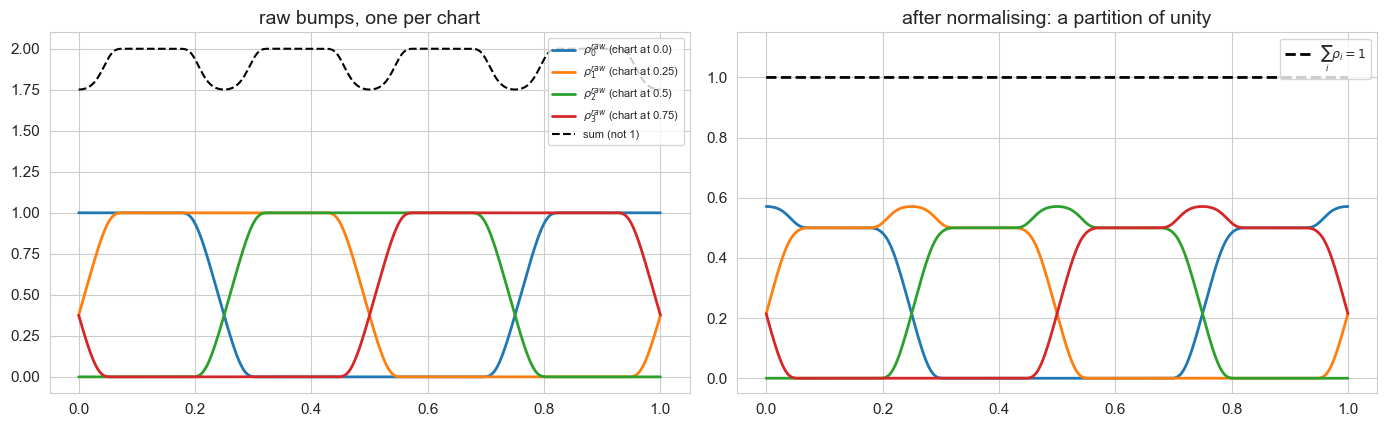

In [9]:
# Build a partition of unity on the circle, subordinate to a 4-chart cover.
centres = np.array([0.0, 0.25, 0.5, 0.75])
half = 0.20            # each chart covers (c-half*1.6, c+half*1.6) in the circle coordinate

def rho_raw(s, c):
    d = (s - c + 0.5) % 1.0 - 0.5          # circular distance
    return bump(d, -0.32, -0.16, 0.16, 0.32)

s = np.linspace(0, 1, 2000)
raw = np.array([rho_raw(s, c) for c in centres])
total = raw.sum(axis=0)
rho = raw / total                          # normalise -> partition of unity

print(f"sum of normalised bumps: min {rho.sum(axis=0).min():.12f}, "
      f"max {rho.sum(axis=0).max():.12f}   (must be exactly 1)")
print(f"each rho_i >= 0 : {bool((rho >= 0).all())}")
print(f"raw cover has no gaps (min total before normalising = {total.min():.4f} > 0)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for i, c in enumerate(centres):
    axes[0].plot(s, raw[i], lw=2, label=f'$\\rho^{{raw}}_{i}$ (chart at {c})')
axes[0].plot(s, total, 'k--', lw=1.5, label='sum (not 1)')
axes[0].legend(fontsize=8); axes[0].set_title("raw bumps, one per chart")
for i in range(len(centres)):
    axes[1].plot(s, rho[i], lw=2)
axes[1].plot(s, rho.sum(axis=0), 'k--', lw=2, label='$\\sum_i \\rho_i = 1$')
axes[1].set_ylim(-.05, 1.15); axes[1].legend(fontsize=9)
axes[1].set_title("after normalising: a partition of unity")
plt.tight_layout(); plt.show()

In [10]:
# The payoff: integrate a function over the circle using ONLY chart-local data.
def g(s):
    return 1.0 + 0.5*np.sin(2*np.pi*s) + 0.3*np.cos(6*np.pi*s)**2

exact = quad(g, 0, 1)[0]

# glue: integral over M = sum_i integral of rho_i * g, each computed in its own chart
pieces = []
for c in centres:
    val = quad(lambda t, c=c: rho_raw(t, c) /
               sum(rho_raw(np.array([t]), cc)[0] for cc in centres) * g(t),
               c - 0.4, c + 0.4, limit=400)[0]
    pieces.append(val)

print(f"{'chart centre':>14} {'∫ rho_i g':>14}")
print("-" * 30)
for c, v in zip(centres, pieces):
    print(f"{c:>14.2f} {v:>14.8f}")
print("-" * 30)
print(f"{'sum':>14} {sum(pieces):>14.8f}")
print(f"{'exact':>14} {exact:>14.8f}")
print(f"{'error':>14} {abs(sum(pieces)-exact):>14.2e}")
print("\nThe global integral was assembled from four purely local computations.")
print("THAT is what second-countability buys. On the long line you cannot do this,")
print("which is why it is excluded from the definition of a manifold.")

  chart centre      ∫ rho_i g
------------------------------
          0.00     0.28848115
          0.25     0.36786042
          0.50     0.28848115
          0.75     0.20517728
------------------------------
           sum     1.15000000
         exact     1.15000000
         error       2.03e-11

The global integral was assembled from four purely local computations.
THAT is what second-countability buys. On the long line you cannot do this,
which is why it is excluded from the definition of a manifold.


---
## 5. Projective space — the quotient worth knowing

$\mathbb{RP}^n$ is the set of **lines through the origin** in $\mathbb{R}^{n+1}$. Equivalently,
the sphere with antipodes glued:

$$\mathbb{RP}^n \;=\; \big(\mathbb{R}^{n+1}\setminus\{0\}\big)\big/(x \sim \lambda x) \;=\; S^n/(p\sim -p)$$

A point is written in **homogeneous coordinates** $[x_0 : x_1 : \cdots : x_n]$, meaning the
whole line, so $[1:2:3] = [2:4:6]$.

It matters because it is the first manifold most people meet that is **not a subset of
$\mathbb{R}^3$** in any obvious way — $\mathbb{RP}^2$ cannot be embedded in $\mathbb{R}^3$ at
all. It is defined purely as a quotient, so charts are the only way to get at it. It is also
where computer vision lives (a camera maps 3-D points to lines of sight, i.e. to
$\mathbb{RP}^2$).

**The standard atlas** has $n+1$ charts. On $U_i = \{[x] : x_i \ne 0\}$, divide through by
$x_i$:

$$\varphi_i([x_0:\cdots:x_n]) = \Big(\tfrac{x_0}{x_i},\dots,\widehat{\tfrac{x_i}{x_i}},\dots,\tfrac{x_n}{x_i}\Big) \in \mathbb{R}^n$$

In [11]:
def rp_normalise(x):
    # canonical representative of a point of RP^n: unit vector with first nonzero entry > 0
    x = np.asarray(x, dtype=float)
    x = x / sla_norm(x)
    nz = np.flatnonzero(np.abs(x) > 1e-12)[0]
    return x if x[nz] > 0 else -x

def chart_i(x, i):
    # RP^n -> R^n on the patch x_i != 0
    x = np.asarray(x, dtype=float)
    if abs(x[i]) < 1e-12:
        return None                       # not in this chart
    return np.delete(x / x[i], i)

def chart_i_inv(u, i, n):
    # R^n -> RP^n
    x = np.insert(np.asarray(u, dtype=float), i, 1.0)
    return rp_normalise(x)

print("homogeneous coordinates: [x] == [lambda x]\n")
for a, b in [([1,2,3],[2,4,6]), ([1,0,0],[-5,0,0]), ([0,1,-1],[0,-3,3])]:
    same = np.allclose(rp_normalise(a), rp_normalise(b))
    print(f"   {a} ~ {b} ?  {same}")

print("\nthe 3-chart atlas on RP^2 covers everything:")
pts = rng.normal(size=(2000, 3))
covered = np.array([any(abs(p[i]) > 1e-12 for i in range(3)) for p in pts])
print(f"   points lying in at least one chart: {covered.sum()}/{len(pts)}")
print("   (a point missed by all three would need x=y=z=0, which is not a point of RP^2)")

print("\nchart round trips on RP^2:")
errs = []
for _ in range(500):
    x = rp_normalise(rng.normal(size=3))
    i = int(np.argmax(np.abs(x)))                 # best-conditioned chart
    errs.append(sla_norm(chart_i_inv(chart_i(x, i), i, 2) - x))
print(f"   max error over 500 random points: {max(errs):.2e}")

homogeneous coordinates: [x] == [lambda x]

   [1, 2, 3] ~ [2, 4, 6] ?  True
   [1, 0, 0] ~ [-5, 0, 0] ?  True
   [0, 1, -1] ~ [0, -3, 3] ?  True

the 3-chart atlas on RP^2 covers everything:
   points lying in at least one chart: 2000/2000
   (a point missed by all three would need x=y=z=0, which is not a point of RP^2)

chart round trips on RP^2:
   max error over 500 random points: 3.34e-16


In [12]:
# Transition maps on RP^2 are rational -> smooth on the overlaps.
print("transition  phi_1 . phi_0^{-1}  on U_0 n U_1:\n")
print(f"{'u = phi_0(x)':>22} {'phi_1(x)':>22} {'closed form (1/u0, u1/u0)':>28}")
print("-" * 76)
for _ in range(5):
    u = rng.normal(size=2)
    if abs(u[0]) < 0.2:
        u[0] = 0.5
    x = chart_i_inv(u, 0, 2)
    v = chart_i(x, 1)
    closed = np.array([1.0/u[0], u[1]/u[0]])
    print(f"{str(np.round(u,4)):>22} {str(np.round(v,4)):>22} {str(np.round(closed,4)):>28}")
print("\nrational in u, with denominator u_0 which is nonzero exactly on the overlap")
print("=> all transition maps are smooth => RP^2 is a smooth 2-manifold.")

transition  phi_1 . phi_0^{-1}  on U_0 n U_1:

          u = phi_0(x)               phi_1(x)    closed form (1/u0, u1/u0)
----------------------------------------------------------------------------
     [ 0.5716 -1.1816]      [ 1.7495 -2.0672]            [ 1.7495 -2.0672]
       [0.5    1.0301]        [2.     2.0603]              [2.     2.0603]
       [-1.071  1.154]      [-0.9337 -1.0775]            [-0.9337 -1.0775]
     [ 0.5    -0.2416]      [ 2.     -0.4831]            [ 2.     -0.4831]
     [-1.6748  1.6056]      [-0.5971 -0.9587]            [-0.5971 -0.9587]

rational in u, with denominator u_0 which is nonzero exactly on the overlap
=> all transition maps are smooth => RP^2 is a smooth 2-manifold.


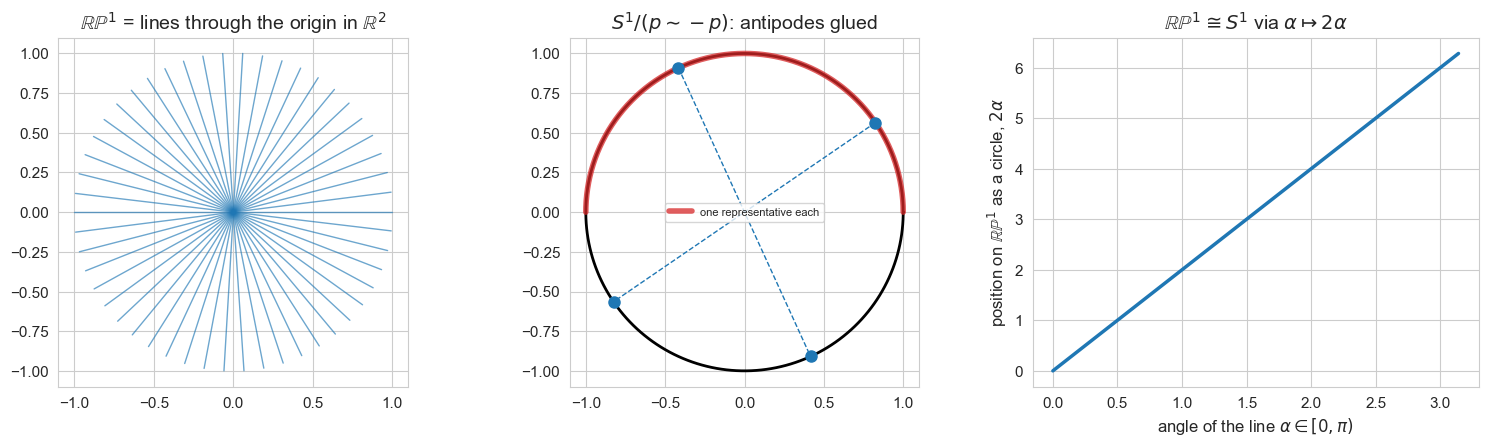

the map [x] -> (cos 2a, sin 2a) is well defined on RP^1 (a and a+pi agree):
   a=2.5077: |f(p) - f(-p)| = 1.11e-16
   a=1.1695: |f(p) - f(-p)| = 2.48e-16
   a=2.2935: |f(p) - f(-p)| = 2.78e-17
   a=0.8765: |f(p) - f(-p)| = 2.50e-16

RP^1 is a circle. RP^2 is NOT a sphere and does not embed in R^3 at all --
it is non-orientable (see section 7), like the Möbius band it contains.


In [13]:
# RP^1 is homeomorphic to a circle: the quotient is a DOUBLE COVER that wraps twice.
th = np.linspace(0, np.pi, 400)                 # half the circle suffices for RP^1
line_dirs = np.column_stack([np.cos(th), np.sin(th)])

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
ax = axes[0]
for d in line_dirs[::16]:
    ax.plot([-d[0], d[0]], [-d[1], d[1]], lw=1, color='C0', alpha=.65)
ax.set_aspect('equal'); ax.set_title("$\\mathbb{RP}^1$ = lines through the origin in $\\mathbb{R}^2$")

ax = axes[1]
full = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(full), np.sin(full), 'k', lw=2)
ax.plot(np.cos(th), np.sin(th), color='C3', lw=4, alpha=.75, label='one representative each')
for a in [0.6, 2.0]:
    ax.plot([np.cos(a), np.cos(a+np.pi)], [np.sin(a), np.sin(a+np.pi)],
            color='C0', lw=1, ls='--')
    ax.plot(np.cos(a), np.sin(a), 'o', color='C0', ms=8)
    ax.plot(np.cos(a+np.pi), np.sin(a+np.pi), 'o', color='C0', ms=8)
ax.set_aspect('equal'); ax.legend(fontsize=8)
ax.set_title("$S^1/(p\\sim -p)$: antipodes glued")

ax = axes[2]
ax.plot(th, 2*th, lw=2.5, color='C0')
ax.set_xlabel("angle of the line $\\alpha \\in [0,\\pi)$")
ax.set_ylabel("position on $\\mathbb{RP}^1$ as a circle, $2\\alpha$")
ax.set_title("$\\mathbb{RP}^1 \\cong S^1$ via $\\alpha \\mapsto 2\\alpha$")
plt.tight_layout(); plt.show()

def rp1_to_circle(x):
    a = np.arctan2(x[1], x[0])
    return np.array([np.cos(2*a), np.sin(2*a)])

print("the map [x] -> (cos 2a, sin 2a) is well defined on RP^1 (a and a+pi agree):")
for _ in range(4):
    a = rng.uniform(0, np.pi)
    p = np.array([np.cos(a), np.sin(a)])
    print(f"   a={a:.4f}: |f(p) - f(-p)| = {sla_norm(rp1_to_circle(p) - rp1_to_circle(-p)):.2e}")
print("\nRP^1 is a circle. RP^2 is NOT a sphere and does not embed in R^3 at all --")
print("it is non-orientable (see section 7), like the Möbius band it contains.")

---
## 6. Things that are *not* manifolds

A clean computable test for "locally Euclidean at $p$": remove $p$ from a small neighbourhood
and count **connected components**. For $\mathbb{R}^1$ you always get **2**; for
$\mathbb{R}^2$ you get **1**. If a point gives a different answer, no chart can exist there.

In [14]:
def components_of_punctured_nbhd(param_pts, centre, R=0.35, r=0.12):
    # count runs of the parameter that lie in the annulus r < |p - centre| < R
    d = np.linalg.norm(param_pts - centre, axis=1)
    inside = (d < R) & (d > r)
    runs, prev = 0, False
    for flag in inside:
        if flag and not prev:
            runs += 1
        prev = flag
    if inside[0] and inside[-1] and runs > 1:     # closed curve wraps around
        runs -= 1
    return runs

t = np.linspace(0, 2*np.pi, 20001)
lemniscate = np.column_stack([np.cos(t) / (1 + np.sin(t)**2),
                              np.cos(t)*np.sin(t) / (1 + np.sin(t)**2)])
circle1 = np.column_stack([np.cos(t) - 1.0, np.sin(t)])     # circle passing through origin

print("punctured-neighbourhood component count (1-dimensional objects):\n")
print(f"{'object':<34}{'at point':<16}{'components':>12}   verdict")
print("-" * 82)
for name, pts, c in [("circle (through the origin)", circle1, np.array([0.0, 0.0])),
                     ("figure-eight (lemniscate)", lemniscate, np.array([0.0, 0.0])),
                     ("figure-eight, ordinary point", lemniscate, lemniscate[2500])]:
    k = components_of_punctured_nbhd(pts, c)
    ok = "locally R^1" if k == 2 else "NOT locally Euclidean"
    print(f"{name:<34}{str(np.round(c,3)):<16}{k:>12}   {ok}")

print("\nThe crossing point of a figure-eight has FOUR branches leaving it.")
print("Removing it splits a small neighbourhood into 4 pieces; removing a point from")
print("R^1 always gives 2. No homeomorphism can exist. Not a manifold at that point.")

punctured-neighbourhood component count (1-dimensional objects):

object                            at point          components   verdict
----------------------------------------------------------------------------------
circle (through the origin)       [0. 0.]                    2   locally R^1
figure-eight (lemniscate)         [0. 0.]                    4   NOT locally Euclidean
figure-eight, ordinary point      [0.471 0.333]              2   locally R^1

The crossing point of a figure-eight has FOUR branches leaving it.
Removing it splits a small neighbourhood into 4 pieces; removing a point from
R^1 always gives 2. No homeomorphism can exist. Not a manifold at that point.


In [15]:
# The cone: a subtler case. Topologically fine, smoothly not.
print("The cone  z = sqrt(x^2 + y^2)  in R^3\n")
print("As a TOPOLOGICAL space it IS a manifold: the radial map")
print("   (x, y, sqrt(x^2+y^2))  <->  (x, y)")
print("is a homeomorphism onto R^2. One chart, done.")
uu = rng.normal(size=(1000, 2))
cone = np.column_stack([uu, np.linalg.norm(uu, axis=1)])
back = cone[:, :2]
print(f"   round trip R^2 -> cone -> R^2 : max error {np.abs(back - uu).max():.2e}\n")

print("But as a SMOOTH SUBMANIFOLD of R^3 it fails at the vertex: there is no tangent plane.")
print("Approach the vertex along different rays and the surface normal does not settle:\n")
print(f"{'direction (deg)':>16} {'unit normal at distance 1e-3':>40}")
print("-" * 58)
for deg in [0, 90, 180, 270]:
    a = np.deg2rad(deg)
    d = np.array([np.cos(a), np.sin(a)])
    # cone as F(x,y,z)=x^2+y^2-z^2=0; normal ~ (2x, 2y, -2z)
    p = np.array([1e-3*d[0], 1e-3*d[1], 1e-3])
    nvec = np.array([2*p[0], 2*p[1], -2*p[2]]); nvec /= sla_norm(nvec)
    print(f"{deg:>16} {str(np.round(nvec, 5)):>40}")
print("\nFour different limits => no well-defined tangent plane at the vertex.")
print("Topological manifold: YES.  Smooth submanifold of R^3: NO.")
print("'Smooth' is genuinely extra data, not a property you get for free.")

The cone  z = sqrt(x^2 + y^2)  in R^3

As a TOPOLOGICAL space it IS a manifold: the radial map
   (x, y, sqrt(x^2+y^2))  <->  (x, y)
is a homeomorphism onto R^2. One chart, done.
   round trip R^2 -> cone -> R^2 : max error 0.00e+00

But as a SMOOTH SUBMANIFOLD of R^3 it fails at the vertex: there is no tangent plane.
Approach the vertex along different rays and the surface normal does not settle:

 direction (deg)             unit normal at distance 1e-3
----------------------------------------------------------
               0             [ 0.70711  0.      -0.70711]
              90             [ 0.       0.70711 -0.70711]
             180             [-0.70711  0.      -0.70711]
             270             [-0.      -0.70711 -0.70711]

Four different limits => no well-defined tangent plane at the vertex.
Topological manifold: YES.  Smooth submanifold of R^3: NO.
'Smooth' is genuinely extra data, not a property you get for free.


closed unit disk D^2 = {|p| <= 1}

interior point p=(0,0): a neighbourhood is an open disk        -> homeomorphic to R^2
boundary point p=(1,0): a neighbourhood is a HALF-disk         -> homeomorphic to
                        the half-plane {(a,b) : b >= 0}, NOT to R^2

R^2 minus a point is connected; the half-plane minus a boundary point is too,
but the half-plane is not homeomorphic to R^2: removing the whole boundary line
disconnects nothing, while R^2 has no such distinguished line.

=> D^2 is a MANIFOLD WITH BOUNDARY, a slightly different (and very useful) object.
   Stokes' theorem lives precisely here.


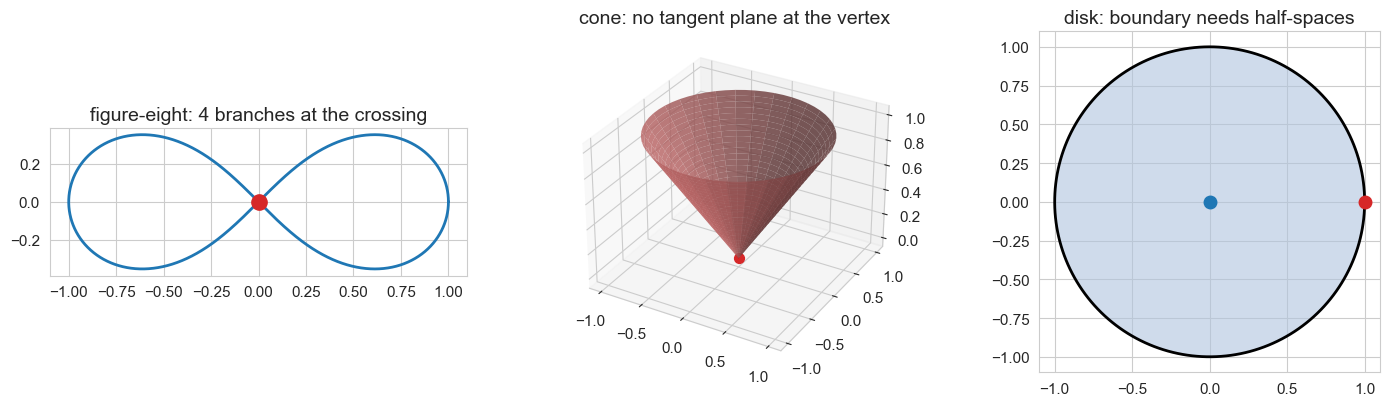

In [16]:
# The closed disk: boundary points are fine, but they need HALF-spaces -> manifold WITH boundary.
print("closed unit disk D^2 = {|p| <= 1}\n")
print("interior point p=(0,0): a neighbourhood is an open disk        -> homeomorphic to R^2")
print("boundary point p=(1,0): a neighbourhood is a HALF-disk         -> homeomorphic to")
print("                        the half-plane {(a,b) : b >= 0}, NOT to R^2")
print("\nR^2 minus a point is connected; the half-plane minus a boundary point is too,")
print("but the half-plane is not homeomorphic to R^2: removing the whole boundary line")
print("disconnects nothing, while R^2 has no such distinguished line.")
print("\n=> D^2 is a MANIFOLD WITH BOUNDARY, a slightly different (and very useful) object.")
print("   Stokes' theorem lives precisely here.")

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
tt = np.linspace(0, 2*np.pi, 400)
axes[0].plot(lemniscate[:,0], lemniscate[:,1], lw=2, color='C0')
axes[0].plot(0, 0, 'o', color='C3', ms=11)
axes[0].set_aspect('equal'); axes[0].set_title("figure-eight: 4 branches at the crossing")

ax = fig.add_subplot(1, 3, 2, projection='3d')
axes[1].remove()
rr, aa = np.mgrid[0:1:30j, 0:2*np.pi:60j]
ax.plot_surface(rr*np.cos(aa), rr*np.sin(aa), rr, color='lightcoral', alpha=.8, linewidth=0)
ax.scatter(0, 0, 0, color='C3', s=50)
ax.set_title("cone: no tangent plane at the vertex")

axes[2].fill(np.cos(tt), np.sin(tt), color='lightsteelblue', alpha=.6)
axes[2].plot(np.cos(tt), np.sin(tt), 'k', lw=2)
axes[2].plot(0, 0, 'o', color='C0', ms=9)
axes[2].plot(1, 0, 'o', color='C3', ms=9)
axes[2].set_aspect('equal'); axes[2].set_title("disk: boundary needs half-spaces")
plt.tight_layout(); plt.show()

---
## 7. Orientability — the Möbius band, computed

A manifold is **orientable** if you can choose a consistent notion of "which way is up"
across the whole space. Locally always possible; globally sometimes not.

The test is concrete: carry a frame (or a normal vector) once around a loop and see whether
it comes back the way it left.

transporting the surface normal once around the Möbius core circle:

   normal at s=0 : [ 0.  0. -1.]
   normal at s=1 : [ 0. -0.  1.]
   dot product   : -1.000000   <- -1 means it came back REVERSED

Same point of the surface, opposite normal => no consistent global choice
=> the Möbius band is NON-ORIENTABLE.

same experiment on a cylinder: dot product +1.000000  -> orientable


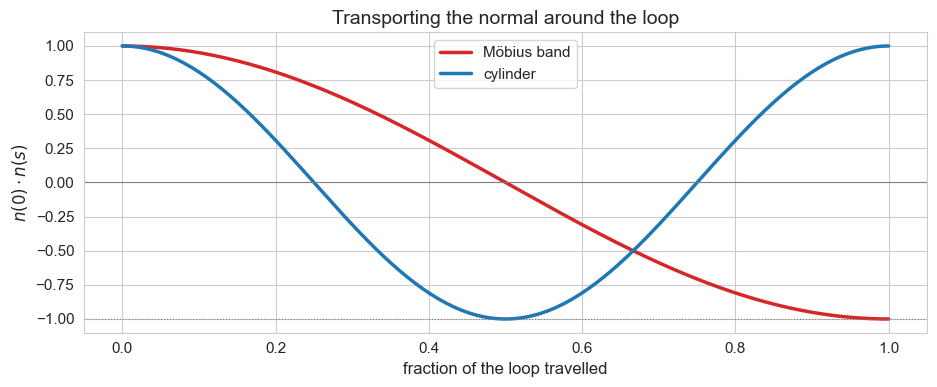

In [17]:
def mobius(s, t, w=0.45):
    a = 2*np.pi*s
    return np.array([(1 + w*t*np.cos(a/2))*np.cos(a),
                     (1 + w*t*np.cos(a/2))*np.sin(a),
                     w*t*np.sin(a/2)])

def surface_normal(s, t, h=1e-6):
    ds = (mobius(s+h, t) - mobius(s-h, t)) / (2*h)
    dt = (mobius(s, t+h) - mobius(s, t-h)) / (2*h)
    n = np.cross(ds, dt)
    return n / sla_norm(n)

n0 = surface_normal(0.0, 0.0)
n1 = surface_normal(1.0 - 1e-9, 0.0)          # after one full trip round the core circle
print("transporting the surface normal once around the Möbius core circle:\n")
print(f"   normal at s=0 : {np.round(n0, 6)}")
print(f"   normal at s=1 : {np.round(n1, 6)}")
print(f"   dot product   : {n0 @ n1:+.6f}   <- -1 means it came back REVERSED")
print("\nSame point of the surface, opposite normal => no consistent global choice")
print("=> the Möbius band is NON-ORIENTABLE.")

# contrast with the cylinder
def cyl(s, t):
    a = 2*np.pi*s
    return np.array([np.cos(a), np.sin(a), 0.45*t])
def cyl_normal(s, t, h=1e-6):
    ds = (cyl(s+h,t) - cyl(s-h,t)) / (2*h); dt = (cyl(s,t+h) - cyl(s,t-h)) / (2*h)
    n = np.cross(ds, dt); return n / sla_norm(n)
c0, c1 = cyl_normal(0.0, 0.0), cyl_normal(1.0-1e-9, 0.0)
print(f"\nsame experiment on a cylinder: dot product {c0 @ c1:+.6f}  -> orientable")

ss = np.linspace(0, 1, 200)
dots = [surface_normal(0.0, 0.0) @ surface_normal(s, 0.0) for s in ss]
fig, ax = plt.subplots(figsize=(9.5, 4))
ax.plot(ss, dots, lw=2.5, color='C3', label='Möbius band')
ax.plot(ss, [c0 @ cyl_normal(s, 0.0) for s in ss], lw=2.5, color='C0', label='cylinder')
ax.axhline(0, color='grey', lw=.8); ax.axhline(-1, color='grey', ls=':', lw=.8)
ax.set_xlabel("fraction of the loop travelled"); ax.set_ylabel("$n(0)\\cdot n(s)$")
ax.set_title("Transporting the normal around the loop")
ax.legend(); plt.tight_layout(); plt.show()

---
## 8. Smooth structure is extra data

$\mathbb{R}$ with the identity chart, and $\mathbb{R}$ with the chart $\psi(x)=x^{3}$, are the
*same topological manifold* — $\psi$ is a homeomorphism. But they define **different smooth
structures**, because the transition map between them,
$\psi^{-1}\circ\mathrm{id} : x \mapsto x^{1/3}$, is **not differentiable at 0**.

So the two atlases are not compatible; their union is not a smooth atlas. "Smooth" is a
choice you make, not a property the space has.

(They happen to be *diffeomorphic* as abstract smooth manifolds — $x\mapsto x^{1/3}$ is a
diffeomorphism between them — so this is not an exotic $\mathbb{R}$. Genuinely inequivalent
smooth structures do exist, famously $2^{8}=28$ of them on $S^{7}$, and uncountably many on
$\mathbb{R}^4$.)

transition map between the identity chart and the x^3 chart is x -> x^(1/3)

           x       d/dx x^(1/3)
--------------------------------
       1e-01             1.5472
       1e-02             7.1815
       1e-03            33.3333
       1e-04           154.7197
       1e-06          3333.3340
        -> 0           diverges

derivative blows up like x^(-2/3): NOT differentiable at 0,
so the two atlases are not smoothly compatible.


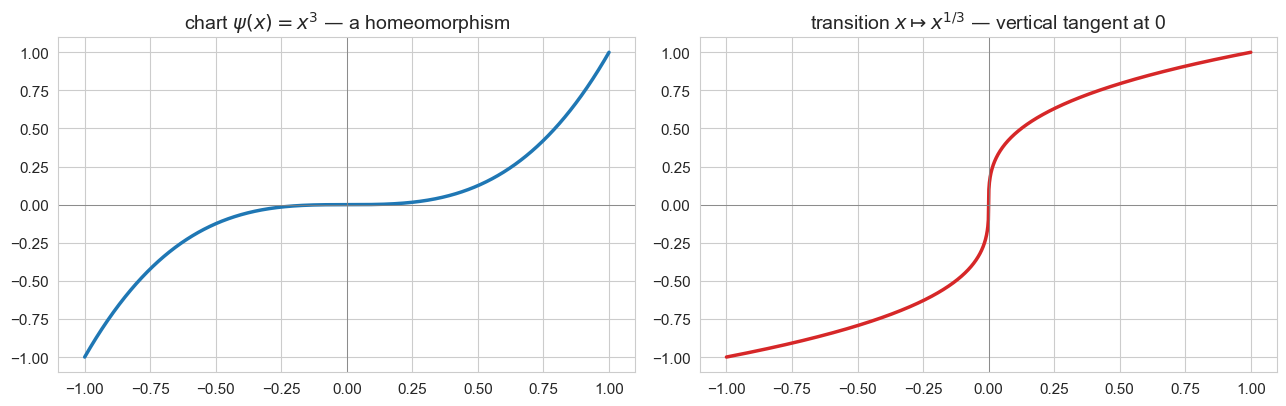

In [18]:
xs = np.linspace(-1, 1, 2001)
cube_root = np.sign(xs) * np.abs(xs)**(1/3)

print("transition map between the identity chart and the x^3 chart is x -> x^(1/3)\n")
print(f"{'x':>12} {'d/dx x^(1/3)':>18}")
print("-" * 32)
for x in [1e-1, 1e-2, 1e-3, 1e-4, 1e-6]:
    h = x*1e-3
    d = ((x+h)**(1/3) - (x-h)**(1/3)) / (2*h)
    print(f"{x:>12.0e} {d:>18.4f}")
print(f"{'-> 0':>12} {'diverges':>18}")
print("\nderivative blows up like x^(-2/3): NOT differentiable at 0,")
print("so the two atlases are not smoothly compatible.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(xs, xs**3, lw=2.5, color='C0')
axes[0].set_title("chart $\\psi(x)=x^3$ — a homeomorphism")
axes[0].axhline(0, color='grey', lw=.6); axes[0].axvline(0, color='grey', lw=.6)
axes[1].plot(xs, cube_root, lw=2.5, color='C3')
axes[1].set_title("transition $x \\mapsto x^{1/3}$ — vertical tangent at 0")
axes[1].axhline(0, color='grey', lw=.6); axes[1].axvline(0, color='grey', lw=.6)
plt.tight_layout(); plt.show()

---
## 9. The bridge: add a metric and you get Riemannian geometry

A manifold on its own has **no lengths and no angles**. Charts tell you what is near what;
they say nothing about how far. That is deliberate — and it is the same pattern as
notebook 08, where a topological/vector structure had to be given an inner product before
geometry appeared.

A **Riemannian metric** is a smoothly varying inner product $g_p(\cdot,\cdot)$ on each tangent
space $T_pM$. Exactly the notebook-08 object, one copy per point. With it you get

$$\text{length}(\gamma) = \int_a^b \sqrt{g_{\gamma(t)}\big(\dot\gamma(t),\dot\gamma(t)\big)}\,dt$$

and hence distances, angles, geodesics, curvature — and eventually general relativity
(notebook 07), where the "inner product" is allowed to be indefinite.

For a surface parameterised by $(u,v)$ the metric is the **first fundamental form**
$\begin{pmatrix} E & F \\ F & G\end{pmatrix}$ with $E=x_u\!\cdot\!x_u$, $F=x_u\!\cdot\!x_v$,
$G=x_v\!\cdot\!x_v$.

In [19]:
# Sphere in spherical coordinates: x(u,v) = (sin u cos v, sin u sin v, cos u)
def S2(u, v):
    return np.array([np.sin(u)*np.cos(v), np.sin(u)*np.sin(v), np.cos(u)])

def first_fundamental_form(u, v, h=1e-6):
    xu = (S2(u+h, v) - S2(u-h, v)) / (2*h)
    xv = (S2(u, v+h) - S2(u, v-h)) / (2*h)
    return np.array([[xu@xu, xu@xv], [xu@xv, xv@xv]])

print("first fundamental form of the unit sphere   (theory: diag(1, sin^2 u))\n")
print(f"{'u (deg)':>9} {'E':>10} {'F':>10} {'G':>10} {'sin^2 u':>12}")
print("-" * 54)
for deg in [30, 60, 90, 120]:
    u = np.deg2rad(deg)
    g = first_fundamental_form(u, 0.7)
    print(f"{deg:>9} {g[0,0]:>10.6f} {g[0,1]:>10.2e} {g[1,1]:>10.6f} {np.sin(u)**2:>12.6f}")
print("\nG shrinks to 0 at the poles: circles of latitude get short. The METRIC")
print("carries that information; the manifold structure alone does not.")

first fundamental form of the unit sphere   (theory: diag(1, sin^2 u))

  u (deg)          E          F          G      sin^2 u
------------------------------------------------------
       30   1.000000  -3.60e-12   0.250000     0.250000
       60   1.000000   1.21e-11   0.750000     0.750000
       90   1.000000   0.00e+00   1.000000     1.000000
      120   1.000000  -8.17e-12   0.750000     0.750000

G shrinks to 0 at the poles: circles of latitude get short. The METRIC
carries that information; the manifold structure alone does not.


path                              length
----------------------------------------


great circle (geodesic)         1.901315


along the latitude circle       1.968088


wobbly detour                   2.454885
----------------------------------------
exact geodesic distance         1.901315   (= the angle between P and Q)

The latitude circle looks like the 'straight' route on a map and is LONGER.
Geodesic != looks straight in a chart. That distinction is the metric's doing.


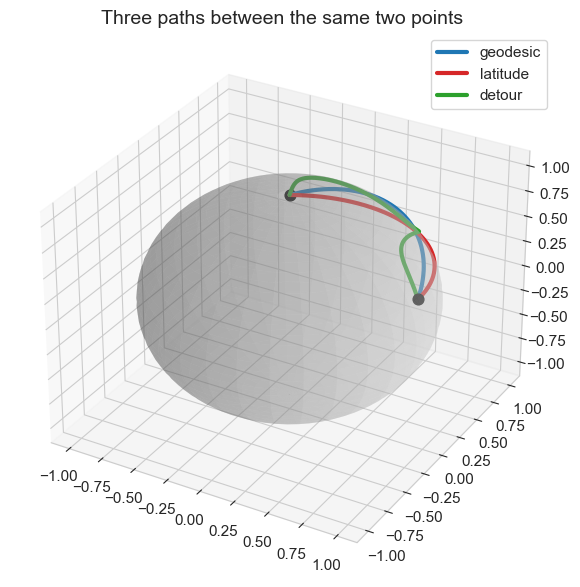

In [20]:
# Geodesics: the great circle really is shortest. Measure with the metric.
def curve_length(gamma, a=0.0, b=1.0, n=20000):
    ts = np.linspace(a, b, n)
    pts = np.array([gamma(t) for t in ts])
    return np.sum(np.linalg.norm(np.diff(pts, axis=0), axis=1))

P = S2(np.deg2rad(70), 0.0)
Q = S2(np.deg2rad(70), np.deg2rad(120))

def great_circle(t):
    om = np.arccos(np.clip(P @ Q, -1, 1))
    return (np.sin((1-t)*om)*P + np.sin(t*om)*Q) / np.sin(om)

def latitude_path(t):
    return S2(np.deg2rad(70), t*np.deg2rad(120))

def wobbly(t):
    base = great_circle(t)
    n = np.cross(P, Q); n /= sla_norm(n)
    return (base + 0.25*np.sin(3*np.pi*t)*n) / sla_norm(base + 0.25*np.sin(3*np.pi*t)*n)

exact = np.arccos(np.clip(P @ Q, -1, 1))
print(f"{'path':<28}{'length':>12}")
print("-" * 40)
for name, c in [("great circle (geodesic)", great_circle),
                ("along the latitude circle", latitude_path),
                ("wobbly detour", wobbly)]:
    print(f"{name:<28}{curve_length(c):>12.6f}")
print("-" * 40)
print(f"{'exact geodesic distance':<28}{exact:>12.6f}   (= the angle between P and Q)")
print("\nThe latitude circle looks like the 'straight' route on a map and is LONGER.")
print("Geodesic != looks straight in a chart. That distinction is the metric's doing.")

fig = plt.figure(figsize=(7.2, 6))
ax = fig.add_subplot(111, projection='3d')
u_, v_ = np.mgrid[0:np.pi:40j, 0:2*np.pi:60j]
ax.plot_surface(np.sin(u_)*np.cos(v_), np.sin(u_)*np.sin(v_), np.cos(u_),
                color='lightgrey', alpha=.3, linewidth=0)
ts = np.linspace(0, 1, 300)
for c, col, lab in [(great_circle, 'C0', 'geodesic'), (latitude_path, 'C3', 'latitude'),
                    (wobbly, 'C2', 'detour')]:
    pth = np.array([c(t) for t in ts])
    ax.plot(*pth.T, lw=3, color=col, label=lab)
ax.scatter(*P, color='k', s=60); ax.scatter(*Q, color='k', s=60)
ax.legend(); ax.set_title("Three paths between the same two points")
plt.tight_layout(); plt.show()

---
## 10. Summary

**The shape of the definition.** A manifold is *locally Euclidean* (so calculus works),
*Hausdorff* (so limits are unique), and *second-countable* (so local things can be glued into
global ones). The last two are not there to give you power — they are there to keep monsters
out.

| Axiom | The monster | What it breaks | § |
|---|---|---|---|
| locally Euclidean | figure-eight | no chart at the crossing (4 branches, not 2) | 6 |
| Hausdorff | line with two origins | $1/n \to 0_a$ **and** $\to 0_b$ | 3 |
| second-countable | the long line | no partitions of unity $\Rightarrow$ no integration | 4 |
| smooth transitions | $\mathbb{R}$ via $x\mapsto x^3$ | $x^{1/3}$ not differentiable at $0$ | 8 |

**Things worth carrying away**

- **Smoothness is a property of transition maps**, never of the space. You always check a map
  $\mathbb{R}^n \to \mathbb{R}^n$ (§1).
- **Quotients are the construction tool** — torus, Möbius, $\mathbb{RP}^n$, and the monsters
  too (§2, §5).
- **Topological $\ne$ smooth.** The cone is a topological manifold with one chart, but has no
  tangent plane at its vertex (§6).
- **Orientability is global.** The Möbius normal comes back negated: $n(0)\cdot n(1) = -1$ (§7).
- **A bare manifold has no lengths.** Charts encode nearness, not distance. The metric is
  separate data (§9).

**Where the series goes from here**

$$\text{Manifold} \;\xrightarrow{\;+\ \text{group structure}\;}\; \text{Lie group (09)}
\qquad
\text{Manifold} \;\xrightarrow{\;+\ \text{metric on } T_pM\;}\; \text{Riemannian (07)}$$

Notebook 09 takes the first branch: $SO(3)$ is a manifold that is also a group, and its
tangent space at the identity is $\mathfrak{so}(3)$. Notebook 07 takes the second: put an
indefinite metric on spacetime and you get general relativity.

---

### References

- [The Bright Side of Mathematics — *Manifolds*](https://www.youtube.com/playlist?list=PLBh2i93oe2qvRGAtgkTszX7szZDVd6jh1),
  59 lectures; this notebook is a computational companion.
- Lee, *Introduction to Smooth Manifolds* — the standard; ch. 1 is exactly §§1–5 here.
- Tu, *An Introduction to Manifolds* — shorter, gentler entry point.
- Milnor, *Topology from the Differentiable Viewpoint* — 64 pages, and worth all of them.
- Lee, *Introduction to Riemannian Manifolds* — for §9 onwards.